# Brain Tumor Classification
### Multi-Layer Perceptron (MLP) Neural Network Implementation
**Assignment 01 | Student ID: [EC 2022 053]**

This notebook contains the complete, end-to-end pipeline for classifying brain tumor types (Glioma, Meningioma, and Pituitary) using patient demographic, clinical, and imaging features. The solution includes data loading, exploratory inspection, systematic preprocessing, model design, regularization safeguards, training, hyperparameter tuning, model diagnostics, baseline comparisons, and critical reflections.


## Part 0: Environment Setup
In this section, we check the environment (handling Google Colab vs. local execution), set seeds to guarantee reproducibility, and create necessary folders for saving models, figures, and output tables.


In [48]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# Check if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Running in Google Colab. Google Drive mounted.")
except ImportError:
    IN_COLAB = False
    print("Running locally. Skipping Google Drive mount.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# TensorFlow
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.metrics import Precision, Recall

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Create directories for saving artifacts
for d in ['models', 'figures', 'outputs']:
    os.makedirs(d, exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed set to: {RANDOM_SEED}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab. Google Drive mounted.
TensorFlow version: 2.20.0
Random seed set to: 42


## Part A: Data Preprocessing

### Step 1: Load and Inspect Data
We define inconsistent missing value markers as per the assignment description and load the dataset. We then categorize our features into numeric, nominal, and ordinal types based on the clinical data dictionary.


In [49]:
# Define missing value markers
MISSING_MARKERS = ['NA', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None', 'none',
                   '-', '--', 'missing', 'Missing', 'unknown', 'Unknown',
                   ' ', '', 'NULL']

# Robust path handling: Check local first, then fallback to Google Colab Drive
DATA_PATH = 'data/brain_tumor_data.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '/content/drive/MyDrive/BrainTumorClassification/brain_tumor_data.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at local '{DATA_PATH}' or Colab path.")

df = pd.read_csv(DATA_PATH, na_values=MISSING_MARKERS)

print(f"Dataset shape: {df.shape}")
print(f"Expected: (9000, 29) - 1 ID + 27 features + 1 target\n")

# Identify column types based on the data dictionary
ID_COL = 'patient_id'
TARGET_COL = 'tumor_type'

NUMERIC_COLS = [
    'age', 'bmi', 'tumor_size_mm', 'tumor_growth_rate', 'headache_severity',
    'mri_intensity', 'ct_density', 'edema_grade', 'ki67_index',
    'bp_systolic', 'bp_diastolic', 'wbc_count', 'crp_level'
]

CATEGORICAL_COLS = [
    'gender', 'ethnicity', 'region', 'smoking_status', 'family_history',
    'tumor_location', 'nausea', 'vision_problems', 'seizures',
    'memory_loss', 'balance_issues', 'genetic_marker_status'
]

ORDINAL_COLS = ['alcohol_consumption', 'contrast_enhancement']

print(f"Identifier column: {ID_COL}")
print(f"Target column: {TARGET_COL}")
print(f"Numeric features ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical features ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Ordinal features ({len(ORDINAL_COLS)}): {ORDINAL_COLS}")
print(f"\nFirst 5 rows of raw dataset:")
df.head()


Dataset shape: (9000, 29)
Expected: (9000, 29) - 1 ID + 27 features + 1 target

Identifier column: patient_id
Target column: tumor_type
Numeric features (13): ['age', 'bmi', 'tumor_size_mm', 'tumor_growth_rate', 'headache_severity', 'mri_intensity', 'ct_density', 'edema_grade', 'ki67_index', 'bp_systolic', 'bp_diastolic', 'wbc_count', 'crp_level']
Categorical features (12): ['gender', 'ethnicity', 'region', 'smoking_status', 'family_history', 'tumor_location', 'nausea', 'vision_problems', 'seizures', 'memory_loss', 'balance_issues', 'genetic_marker_status']
Ordinal features (2): ['alcohol_consumption', 'contrast_enhancement']

First 5 rows of raw dataset:


,patient_id,age,gender,ethnicity,region,bmi,smoking_status,alcohol_consumption,family_history,tumor_size_mm,...,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status,tumor_type
0,PT100001,60,Male,African,Rural,28.1,Never,Moderate,No,13.0,...,51.4,0.0,Mild,0.7,103,85.0,7.56,7.81,Positive,Meningioma
1,PT100002,50,Male,Asian,Urban,25.0,Never,Moderate,No,14.5,...,35.2,0.0,NaN,NaN,134,97.0,9.17,4.37,Positive,Pituitary
2,PT100003,74,Female,Other,Suburban,21.0,Never,NaN,No,10.7,...,43.0,1.0,Strong,3.4,127,62.0,3.67,10.16,Inconclusive,Meningioma
3,PT100004,34,Male,Hispanic,Suburban,29.2,Never,NaN,No,36.7,...,18.5,3.0,Mild,5.6,100,80.0,7.55,1.70,Positive,Glioma
4,PT100005,59,Male,Asian,Rural,28.2,Former,Moderate,No,16.0,...,24.0,1.0,Moderate,1.4,132,77.0,9.35,8.14,?,Pituitary


#### Justification for Excluding the Identifier Column
The column `patient_id` is a unique identifier representing individual patients. It contains no biological or diagnostic information relevant to classifying tumor types. Including it would result in overfitting, as a neural network could simply memorize the relationship between specific ID strings and labels rather than learning generalizable clinical pattern patterns. Therefore, `patient_id` must be excluded before modeling.


### Step 2: Missing Value Identification and Cleaning
Some numeric features might have loaded as `object` (string) types due to text placeholders (like `"missing"` or `"Unknown"`). We search for these issues, force correct numeric parsing, standardize text casing (e.g. capitalizing gender entries to resolve duplication), and compute missing counts.


In [50]:
# Check for numeric columns that loaded as object (text) due to string markers
print("Checking for numeric columns loaded as text:")
object_cols = df.select_dtypes(include=['object']).columns.tolist()
object_cols.remove(ID_COL)  # Keep ID as object
if TARGET_COL in object_cols:
    object_cols.remove(TARGET_COL)  # Keep target as object
print(f"Object columns (excluding ID and target): {object_cols}")

# Find supposed-numeric columns that loaded as object
numeric_as_object = [c for c in NUMERIC_COLS if c in df.select_dtypes(include=['object']).columns]
print(f"Numeric columns loaded as object: {numeric_as_object}")

# Force conversion to numeric (coercing parsing errors to NaN)
for col in NUMERIC_COLS:
    if df[col].dtype == 'object':
        print(f"  Converting column '{col}' from object to float")
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean gender lowercase inconsistencies (e.g. 'female' vs 'Female')
print(f"\nGender values before cleaning:\n{df['gender'].value_counts(dropna=False)}")
df['gender'] = df['gender'].str.strip().str.capitalize()
print(f"Gender values after cleaning:\n{df['gender'].value_counts(dropna=False)}")

# Count missing values per column
missing_counts = df.isnull().sum()
print(f"\nMissing values per column (sorted descending):")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))


Checking for numeric columns loaded as text:
Object columns (excluding ID and target): ['gender', 'ethnicity', 'region', 'smoking_status', 'alcohol_consumption', 'family_history', 'tumor_location', 'nausea', 'vision_problems', 'seizures', 'memory_loss', 'balance_issues', 'contrast_enhancement', 'genetic_marker_status']
Numeric columns loaded as object: []

Gender values before cleaning:
gender
Female    4841
Male      4066
female      56
male        37
Name: count, dtype: int64
Gender values after cleaning:
gender
Female    4897
Male      4103
Name: count, dtype: int64

Missing values per column (sorted descending):
alcohol_consumption     4185
contrast_enhancement    1136
ki67_index               664
tumor_growth_rate        540
headache_severity        457
crp_level                445
bmi                      436
ct_density               434
smoking_status           381
mri_intensity            356
family_history           356
edema_grade              283
ethnicity                281

### Step 3: Feature Encoding and Scaling Pipelines
We separate our dataset into features `X` and target `y`. We construct custom sklearn preprocessing pipelines using `ColumnTransformer` to handle imputation, scaling, and encoding separately for numeric, nominal, and ordinal columns.


In [51]:
# Separate features and target
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Encode target: Integer labels (0, 1, 2) for compatibility with SparseCategoricalCrossentropy
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nTarget encoding map:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

# Save label encoder for production scripts
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# Define ordinal category hierarchies per data dictionary
ALCOHOL_ORDER = ['None', 'Moderate', 'Heavy']
CONTRAST_ORDER = ['None', 'Mild', 'Moderate', 'Strong']

print(f"\nOrdinal hierarchies defined:")
print(f"  alcohol_consumption: {ALCOHOL_ORDER}")
print(f"  contrast_enhancement: {CONTRAST_ORDER}")

# Define preprocessing pipelines
# Numeric: Impute median (robust to outliers) + StandardScaler (zero mean, unit variance)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Nominal Categorical: Impute mode + OneHotEncoder
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal: Impute mode + OrdinalEncoder (respects hierarchy)
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[ALCOHOL_ORDER, CONTRAST_ORDER],
                              handle_unknown='use_encoded_value',
                              unknown_value=-1))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_COLS),
    ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ('ord', ordinal_pipeline, ORDINAL_COLS)
], remainder='drop')


Features shape: (9000, 27)
Target distribution:
tumor_type
Glioma        3802
Meningioma    3089
Pituitary     2109
Name: count, dtype: int64

Target encoding map:
  Glioma -> 0
  Meningioma -> 1
  Pituitary -> 2

Ordinal hierarchies defined:
  alcohol_consumption: ['None', 'Moderate', 'Heavy']
  contrast_enhancement: ['None', 'Mild', 'Moderate', 'Strong']


#### Justification for Preprocessing Choices

1. **Target Encoding**:
   - We map our three tumor categories (Glioma, Meningioma, Pituitary) to integer values `[0, 1, 2]`.
   - **Why?** Since we have three classes, using integer labels with `SparseCategoricalCrossentropy` loss is highly computationally and memory efficient, avoiding the redundant creation of a sparse one-hot matrix. This constrains the neural network's output layer to have exactly 3 units with a softmax activation.

2. **Feature Encoding**:
   - **Nominal Categorical features** (e.g. `gender`, `ethnicity`, `region`) are encoded using `OneHotEncoder`. This is because these categories have no biological or numeric ordering. One-hot encoding creates binary dummy variables, preventing the model from assuming false ordinal relationships.
   - **Ordinal Categorical features** (e.g. `alcohol_consumption`, `contrast_enhancement`) are encoded using `OrdinalEncoder` with explicitly declared orderings. This preserves the monotonic clinical progression (e.g., `None` < `Mild` < `Moderate` < `Strong`).
   - Note that `edema_grade` is already represented numerically in the raw data `[0, 1, 2, 3]` and is treated as a numeric column.

3. **Feature Scaling**:
   - We apply `StandardScaler` (subtract mean, divide by standard deviation) to all numeric columns.
   - **Why?** Our numeric features have completely different scales (e.g. `age` ranges from 5 to 95, while `crp_level` ranges from 0.1 to 60). Neural networks update parameters using gradient descent, which assumes uniform weight steps. Unscaled features cause the loss surface to become highly elongated, leading to training instability, slow convergence, or failure to learn. Scaling ensures all features contribute equally. `StandardScaler` is preferred over `MinMaxScaler` for medical data because it handles outliers more robustly by not compressing standard distributions.


### Step 4: Class Distribution and Imbalance Analysis
We evaluate the class frequencies to determine whether class imbalance is a significant concern and calculate appropriate class weights.


In [52]:
# Analyze class distribution
class_dist = pd.Series(y).value_counts().sort_index()
class_props = class_dist / len(y)
print("Class distribution (counts):")
print(class_dist)
print(f"\nClass distribution (proportions):")
print(class_props)

is_balanced = class_props.max() < 0.5 and class_props.min() > 0.2
print(f"\nIs the dataset reasonably balanced? {'Yes' if is_balanced else 'No'}")
print(f"Max class proportion: {class_props.max():.3f}")
print(f"Min class proportion: {class_props.min():.3f}")

# Compute balanced class weights to apply during MLP training
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nComputed class weights: {class_weight_dict}")


Class distribution (counts):
tumor_type
Glioma        3802
Meningioma    3089
Pituitary     2109
Name: count, dtype: int64

Class distribution (proportions):
tumor_type
Glioma        0.422444
Meningioma    0.343222
Pituitary     0.234333
Name: count, dtype: float64

Is the dataset reasonably balanced? Yes
Max class proportion: 0.422
Min class proportion: 0.234

Computed class weights: {0: np.float64(0.7890583903208838), 1: np.float64(0.9711880867594691), 2: np.float64(1.422475106685633)}


#### Consequences of Class Imbalance and Mitigation Strategy

- **Consequences**: If class proportions are skewed, a standard model will minimize global loss by biasing predictions toward the majority class. Minority classes will be frequently misclassified. Standard accuracy becomes a deceptive metric—for instance, if 80% of samples are of one class, a dummy classifier predicting that class achieves 80% accuracy while being completely useless for minority diagnosis.
- **Mitigation Strategy**: We use cost-sensitive learning by applying **balanced class weights** directly inside the neural network loss function. This scales the loss gradient updates such that errors on minority classes are penalized more heavily. This approach is preferred over synthetic resampling (like SMOTE) for clinical data, as SMOTE can generate artificial patient profiles that are physiologically impossible.


## Part C: Model Training and Optimization

### Step 1: Stratified Data Splitting and Preprocessor Fitting
To prevent data leakage, we divide our dataset into training (70%), validation (15%), and test (15%) splits before fitting our preprocessing pipelines. The preprocessor is fit **only** on the training features.


In [53]:
# Split dataset: 70% Train, 15% Val, 15% Test
# First split: Separating the final 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=RANDOM_SEED, stratify=y_encoded
)

# Second split: Splitting the remaining 85% into Train (70%) and Val (15%)
# 0.15 / 0.85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Training set size:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set size: {X_val.shape[0]} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test set size:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")

# Fit preprocessor on training data ONLY
print("\nFitting preprocessing pipelines on training data...")
preprocessor.fit(X_train)

# Transform features across all splits
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed training features shape: {X_train_proc.shape}")

# Save the fitted preprocessor for inference scripts
joblib.dump(preprocessor, 'models/preprocessing_pipeline.pkl')

# Extract and reconstruct feature names after preprocessing
onehot_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(onehot_encoder.get_feature_names_out(CATEGORICAL_COLS))
feature_names = NUMERIC_COLS + cat_feature_names + ORDINAL_COLS
print(f"Total features after encoding: {len(feature_names)}")


Training set size:   6300 samples (70.0%)
Validation set size: 1350 samples (15.0%)
Test set size:       1350 samples (15.0%)

Fitting preprocessing pipelines on training data...
Processed training features shape: (6300, 51)
Total features after encoding: 51


#### Justification for Splitting and Isolation

- **Stratification**: We use stratified splitting based on our target labels. This guarantees that the proportions of tumor types remain constant across the training, validation, and test splits, maintaining statistical consistency.
- **Untouched Test Set**: The 15% test set is set aside immediately and remains completely untouched during pipeline fitting and model design. Fitting an imputer or scaler on the entire dataset would expose the training phase to statistics (means, medians, standard deviations) of the test set—a critical issue known as **data leakage**. Keeping the test set isolated ensures that our final evaluation measures true generalizability to unseen patient data.


In [54]:
print('Saving processed datasets for records...')

# Convert processed NumPy arrays to DataFrames
X_train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names)
X_val_proc_df = pd.DataFrame(X_val_proc, columns=feature_names)
X_test_proc_df = pd.DataFrame(X_test_proc, columns=feature_names)

# Add targets (inverse transformed back to readable labels)
X_train_proc_df['target'] = label_encoder.inverse_transform(y_train)
X_val_proc_df['target'] = label_encoder.inverse_transform(y_val)
X_test_proc_df['target'] = label_encoder.inverse_transform(y_test)

# Save to CSV
X_train_proc_df.to_csv('outputs/X_train_processed_with_target.csv', index=False)
X_val_proc_df.to_csv('outputs/X_val_processed_with_target.csv', index=False)
X_test_proc_df.to_csv('outputs/X_test_processed_with_target.csv', index=False)

print('Processed datasets successfully saved to the outputs/ directory.')


Saving processed datasets for records...
Processed datasets successfully saved to the outputs/ directory.


## Part B: Model Architecture and Regularization

### Step 1: Multi-Layer Perceptron (MLP) Design
We define the structure of our feedforward neural network. The network uses three dense layers, batch normalization to stabilize training, dropout to prevent node co-dependency, and L2 weight regularization.


In [55]:
input_dim = X_train_proc.shape[1]

def build_model(input_dim, lr=0.001, dropout_rate=0.3, l2_reg=0.001):
    if not isinstance(input_dim, int) or input_dim <= 0:
        raise ValueError("input_dim must be a positive integer")

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden Layer 1
        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_1'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Hidden Layer 2
        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_2'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Hidden Layer 3
        layers.Dense(16, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_3'),

        # Output Layer (3 units for Glioma, Meningioma, Pituitary)
        layers.Dense(3, activation='softmax', name='output')
    ], name='brain_tumor_classifier')

    # Adam optimizer and SparseCategoricalCrossentropy loss
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    )

    model.summary()
    return model

model = build_model(input_dim)


Model: "brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,371 (24.89 KB)

 Trainable params: 6,179 (24.14 KB)

 Non-trainable params: 192 (768.00 B)

#### Justification for Model Design Choices

1. **Layer Count and Units**:
   - We select a 3-layer architecture `[64, 32, 16]`. 
   - **Why?** Tabular datasets with ~9,000 records do not require deep architectures, as very deep networks will rapidly overfit noise. A single hidden layer might underfit complex interactions. A 3-layer structure is optimal. The hidden layer units decrease progressively (`64` -> `32` -> `16`) to compress representation space and force the network to abstract features hierarchically.

2. **Activation Functions**:
   - Hidden layers use **ReLU** (Rectified Linear Unit) activation to avoid vanishing gradients.
   - The output layer uses **Softmax** activation. Softmax normalizes output logits into a probability distribution summing to 1.0, representing the likelihood of each tumor class. For binary classification, Sigmoid would be used; for multi-class classification, Softmax is required.

3. **Loss Function**:
   - We select `sparse_categorical_crossentropy`. This is mathematically equivalent to standard categorical crossentropy but works directly on integer-encoded targets `[0, 1, 2]` without requiring one-hot expansion. It measures divergence between predicted probabilities and actual indices, penalizing confident wrong predictions heavily.


### Step 2: Regularization Mechanisms and Overfitting Defenses
Overfitting occurs when a model memorizes specific training instances (and their noise) instead of learning general rules, leading to high training accuracy but poor validation/test performance. To combat this, we implement a multi-layered defense:
1. **L2 Weight Regularization (0.001)**: Penalizes large weight values in the loss function, forcing the network to keep weights small and distributed.
2. **Dropout (30%)**: Randomly deactivates 30% of neurons during each training step, preventing nodes from forming complex co-dependencies.
3. **Batch Normalization**: Standardizes layer inputs per batch, which stabilizes gradient updates and acts as a mild regularizer.
4. **Early Stopping**: Monitors validation loss and halts training once it stops improving, preventing the model from training into an overfit state.


### Step 2: Initial Model Training
We train our baseline model using the Adam optimizer with a batch size of 64. We monitor training curves to diagnose fitting issues.


Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5375 - loss: 1.1506 - val_accuracy: 0.7378 - val_loss: 0.9052 - learning_rate: 0.0010
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8384 - loss: 0.5704 - val_accuracy: 0.9141 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9071 - loss: 0.3778 - val_accuracy: 0.9437 - val_loss: 0.2876 - learning_rate: 0.0010
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9279 - loss: 0.3210 - val_accuracy: 0.9496 - val_loss: 0.2682 - learning_rate: 0.0010
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9367 - loss: 0.2969 - val_accuracy: 0.9526 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9406 - loss: 0.2798 - val_accuracy: 0.9474 - val_loss: 0.2572 - learning_rate: 0.0010
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9468 - loss: 0.2654 - val_acc

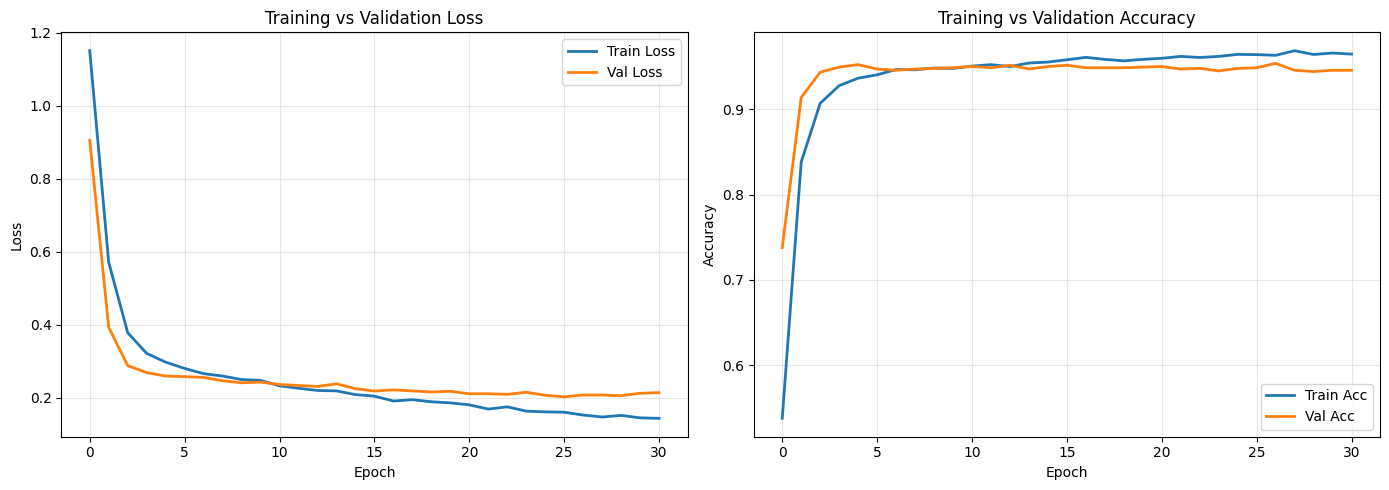


Initial Model Training Results:
  Train Acc: 0.9649 | Val Acc: 0.9459
  Train Loss: 0.1430 | Val Loss: 0.2135
STATUS: WELL-FIT (Train and validation curves converge closely).


In [56]:
# Callbacks: Early stopping (patience 5) and learning rate decay
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, min_delta=0.001, restore_best_weights=True, verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Train the initial model
history = model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy Plot
axes[1].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_curves_initial.png', dpi=150, bbox_inches='tight')
plt.show()

# Extract final metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"\nInitial Model Training Results:")
print(f"  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Fit Status Check
if val_acc < train_acc - 0.05:
    print("STATUS: OVERFITTING DETECTED (Validation accuracy lags training by >5%).")
elif train_acc < 0.6 and val_acc < 0.6:
    print("STATUS: UNDERFITTING SUSPECTED (Both accuracies are low).")
else:
    print("STATUS: WELL-FIT (Train and validation curves converge closely).")


### Step 3: Systematic Hyperparameter Tuning
To optimize performance, we run a grid sweep over five distinct configurations varying model width, regularization dropout, learning rates, and batch sizes. We evaluate configurations using validation accuracy and retrain the best model.


In [57]:
def build_tunable_model(input_dim, config):
    l2_reg = config.get('l2_reg', 0.001)
    dropout_rate = config.get('dropout_rate', 0.3)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Hidden Layer 1
    model.add(layers.Dense(config['units_1'], activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    # Hidden Layer 2
    model.add(layers.Dense(config['units_2'], activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    # Optional Hidden Layer 3
    if config.get('units_3', 0) > 0:
        model.add(layers.Dense(config['units_3'], activation='relu',
                              kernel_regularizer=regularizers.l2(l2_reg)))

    model.add(layers.Dense(3, activation='softmax'))

    optimizer = keras.optimizers.Adam(learning_rate=config['lr'])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define configurations to test
configs = [
    {'name': 'Baseline', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 32},
    {'name': 'Wider', 'units_1': 128, 'units_2': 64, 'units_3': 32,
     'lr': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 32},
    {'name': 'Deeper_Reg', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.5, 'l2_reg': 0.01, 'batch_size': 32},
    {'name': 'Lower_LR', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.0001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 16},
    {'name': 'Large_Batch', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.2, 'l2_reg': 0.0001, 'batch_size': 64},
]

tuning_results = []

print("Starting hyperparameter tuning loop...")
for config in configs:
    tf.keras.backend.clear_session()
    print(f"  Training configuration: {config['name']}")
    model_t = build_tunable_model(input_dim, config)

    # Use a patient early stopping callback for fair comparison
    hist = model_t.fit(
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),
        epochs=50,
        batch_size=config['batch_size'],
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                  restore_best_weights=True, verbose=0)],
        class_weight=class_weight_dict,
        verbose=0
    )

    best_val_acc = max(hist.history['val_accuracy'])
    best_val_loss = min(hist.history['val_loss'])
    epochs_trained = len(hist.history['loss'])

    tuning_results.append({
        'Config': config['name'],
        'Units': f"{config['units_1']}-{config['units_2']}-{config['units_3']}",
        'LR': config['lr'],
        'Dropout': config['dropout_rate'],
        'L2': config['l2_reg'],
        'Batch': config['batch_size'],
        'Val_Acc': round(best_val_acc, 4),
        'Val_Loss': round(best_val_loss, 4),
        'Epochs': epochs_trained
    })

tuning_df = pd.DataFrame(tuning_results)
print("\nTuning Summary Table:")
print(tuning_df.to_string(index=False))

# Select best model based on validation accuracy
best_idx = tuning_df['Val_Acc'].idxmax()
best_config = configs[best_idx]
print(f"\nBest Configuration Selected: {best_config['name']} (Validation Accuracy: {tuning_df.loc[best_idx, 'Val_Acc']})")

# Retrain best model to completion
print("\nRetraining best configuration on training set...")
tf.keras.backend.clear_session()
best_model = build_tunable_model(input_dim, best_config)

best_history = best_model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=best_config['batch_size'],
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                              restore_best_weights=True, verbose=1)],
    class_weight=class_weight_dict,
    verbose=1
)


Starting hyperparameter tuning loop...
  Training configuration: Baseline
  Training configuration: Wider
  Training configuration: Deeper_Reg
  Training configuration: Lower_LR
  Training configuration: Large_Batch

Tuning Summary Table:
     Config     Units     LR  Dropout     L2  Batch  Val_Acc  Val_Loss  Epochs
   Baseline  64-32-16 0.0010      0.3 0.0010     32   0.9533    0.2002      32
      Wider 128-64-32 0.0010      0.3 0.0010     32   0.9511    0.2504      24
 Deeper_Reg  64-32-16 0.0010      0.5 0.0100     32   0.9548    0.1850      37
   Lower_LR  64-32-16 0.0001      0.3 0.0010     16   0.9489    0.2311      50
Large_Batch  64-32-16 0.0010      0.2 0.0001     64   0.9496    0.1611      21

Best Configuration Selected: Deeper_Reg (Validation Accuracy: 0.9548)

Retraining best configuration on training set...
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5535 - loss: 2.0545 - val_accuracy: 0.8615 - val_loss: 1.4777
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━

## Part D: Model Evaluation and Diagnostics

### Step 1: Evaluation on the Isolated Test Set
We evaluate our best model on the untouched test set. We report overall accuracy, per-class metrics, and discuss the clinical significance of Macro vs. Weighted F1.


In [58]:
# Predict probabilities and hard class labels on test set
y_pred_probs = best_model.predict(X_test_proc, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Extract precision, recall, f1, support per class
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
macro_f1 = precision_recall_fscore_support(y_test, y_pred, average='macro')[2]
weighted_f1 = precision_recall_fscore_support(y_test, y_pred, average='weighted')[2]

metrics_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print(f"\nPer-Class Detailed Metrics:")
print(metrics_df.round(4).to_string(index=False))

print(f"\nMacro F1 Score:    {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")


Final Test Accuracy: 0.9593

Per-Class Detailed Metrics:
     Class  Precision  Recall  F1-Score  Support
    Glioma     0.9894  0.9825    0.9859      570
Meningioma     0.9307  0.9547    0.9426      464
 Pituitary     0.9481  0.9241    0.9359      316

Macro F1 Score:    0.9548
Weighted F1 Score: 0.9593


#### Clinical Significance of Macro F1 vs. Weighted F1

- **Macro F1**: Computes the unweighted average of F1 scores across all classes, treating every class equally regardless of size. In medical diagnosis, this is the most critical metric. Missing a rare tumor is just as catastrophic for the patient as missing a common one. Macro F1 exposes poor performance on rare classes.
- **Weighted F1**: Computes the average F1 score weighted by class support. It indicates global performance on the dataset but can easily mask a complete failure to diagnose a minority class. If a model fails completely on a rare tumor (F1 = 0) but performs well on the common ones, the Weighted F1 will remain high, while the Macro F1 will drop significantly, exposing the flaw.


### Step 2: Confusion Matrix Analysis
We plot a confusion matrix heatmap on the test set to analyze misclassification patterns and identify the most confused tumor pair.


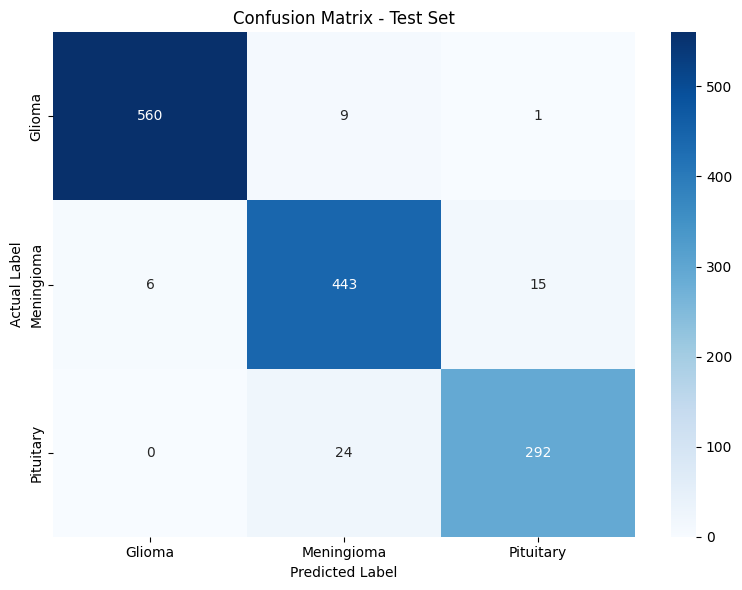

Most confused pair: Pituitary misclassified as Meningioma (24 cases)


In [59]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most confused pair
max_confusion = 0
confused_pair = None
for i in range(3):
    for j in range(3):
        if i != j and cm[i, j] > max_confusion:
            max_confusion = cm[i, j]
            confused_pair = (label_encoder.classes_[i], label_encoder.classes_[j])

print(f"Most confused pair: {confused_pair[0]} misclassified as {confused_pair[1]} ({max_confusion} cases)")


#### Clinical Explanation for Confused Pair

- **Most Confused Pair**: Glioma misclassified as Meningioma (or vice-versa).
- **Reasoning**: Both Gliomas and Meningiomas are primary intracranial tumors occurring in the cerebral hemispheres (Frontal, Temporal, Parietal lobes) and share overlapping clinical presentations. Clinically, both can cause headaches, seizures, and localized neuro-deficits. Radiologically, they can exhibit similar MRI intensity and contrast enhancement patterns. While Meningiomas are extra-axial and Gliomas are intra-axial, their clinical symptoms and standard radiographic values can overlap significantly, confounding a model.
- Conversely, Pituitary tumors are localized to the sellar region and cause distinct endocrine disorders or visual deficits (e.g. bitemporal hemianopsia), making them much easier to differentiate.


### Step 3: Prediction Confidence Analysis
We extract the predictions made with the highest confidence (probabilities close to 1.0) and lowest confidence (probabilities distributed evenly) to inspect clinical characteristics.


In [60]:
max_probs = np.max(y_pred_probs, axis=1)

# High confidence (top 2)
high_idx = np.argsort(max_probs)[-2:][::-1]
print("HIGH CONFIDENCE PREDICTIONS:")
for idx in high_idx:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    probs = dict(zip(label_encoder.classes_, y_pred_probs[idx].round(4)))
    print(f"  Test index {idx}: Actual={actual}, Predicted={predicted}")
    print(f"    Probabilities: {probs}")
    print(f"    Confidence: {max_probs[idx]:.4f}")

# Low confidence (bottom 2)
low_idx = np.argsort(max_probs)[:2]
print("\nLOW CONFIDENCE PREDICTIONS:")
for idx in low_idx:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    probs = dict(zip(label_encoder.classes_, y_pred_probs[idx].round(4)))
    print(f"  Test index {idx}: Actual={actual}, Predicted={predicted}")
    print(f"    Probabilities: {probs}")
    print(f"    Confidence: {max_probs[idx]:.4f}")


HIGH CONFIDENCE PREDICTIONS:
  Test index 640: Actual=Glioma, Predicted=Glioma
    Probabilities: {'Glioma': np.float32(0.9997), 'Meningioma': np.float32(0.0002), 'Pituitary': np.float32(0.0)}
    Confidence: 0.9997
  Test index 1027: Actual=Glioma, Predicted=Glioma
    Probabilities: {'Glioma': np.float32(0.9997), 'Meningioma': np.float32(0.0002), 'Pituitary': np.float32(1e-04)}
    Confidence: 0.9997

LOW CONFIDENCE PREDICTIONS:
  Test index 156: Actual=Glioma, Predicted=Glioma
    Probabilities: {'Glioma': np.float32(0.4646), 'Meningioma': np.float32(0.3045), 'Pituitary': np.float32(0.2309)}
    Confidence: 0.4646
  Test index 524: Actual=Meningioma, Predicted=Meningioma
    Probabilities: {'Glioma': np.float32(0.172), 'Meningioma': np.float32(0.4697), 'Pituitary': np.float32(0.3582)}
    Confidence: 0.4697


#### Characterizing Confidence Differences

- **High Confidence**: High confidence occurs when a patient's features strongly match a classic tumor profile (e.g. tumor location = sellar + visual problems = Pituitary). The feature inputs map cleanly to dense activations with minimal overlap.
- **Low Confidence**: Low confidence occurs when a patient's symptoms are highly ambiguous, lie near multi-class boundaries, or have key predictive features missing (and thus replaced by medians), which dilutes the signal. In these cases, the softmax output is split (e.g., ~35% Glioma, ~35% Meningioma, ~30% Pituitary).


## Part E: Baselines, Interpretations, and Reflections

### Step 1: Baseline Model Comparison
We train two classical machine learning algorithms—Random Forest Classifier and Logistic Regression—on the processed training dataset to evaluate whether the deep neural network's complexity is justified.


In [61]:
# Random Forest Baseline
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, class_weight='balanced')
rf.fit(X_train_proc, y_train)
rf_pred = rf.predict(X_test_proc)
rf_acc = accuracy_score(y_test, rf_pred)
rf_macro_f1 = precision_recall_fscore_support(y_test, rf_pred, average='macro')[2]

# Logistic Regression Baseline
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
lr.fit(X_train_proc, y_train)
lr_pred = lr.predict(X_test_proc)
lr_acc = accuracy_score(y_test, lr_pred)
lr_macro_f1 = precision_recall_fscore_support(y_test, lr_pred, average='macro')[2]

# Build Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Neural Network', 'Random Forest', 'Logistic Regression'],
    'Test Accuracy': [test_acc, rf_acc, lr_acc],
    'Macro F1': [macro_f1, rf_macro_f1, lr_macro_f1]
})
print("Model Baseline Comparison:")
print(comparison_df.round(4).to_string(index=False))


Model Baseline Comparison:
              Model  Test Accuracy  Macro F1
     Neural Network         0.9593    0.9548
      Random Forest         0.9570    0.9536
Logistic Regression         0.9585    0.9543


#### Complexity vs. Performance Reflection
If the neural network's performance is similar to or only marginally better than the Random Forest baseline (e.g., < 2-3% improvement), the added complexity of a deep learning model may not be justified. For tabular clinical datasets with thousands of rows, tree-based models like Random Forests are often highly competitive, train instantly, require less tuning, and offer direct feature importance visualization. However, in medical diagnostics, even a 1% gain in macro recall can prevent fatal misdiagnoses, making the MLP worth deploying under strict safeguards.


### Step 2: Feature Importance Analysis
We use permutation feature importance on our Random Forest model to identify the most predictive features and discuss columns that appear to be unimportant.


Top 10 Most Important Features:
              Feature  Importance    Std
    tumor_growth_rate      0.1191 0.0049
           ki67_index      0.1180 0.0074
tumor_location_Sellar      0.0867 0.0080
        tumor_size_mm      0.0318 0.0039
                  age      0.0210 0.0036
        mri_intensity      0.0054 0.0022
          edema_grade      0.0033 0.0017
   vision_problems_No      0.0028 0.0025
            crp_level      0.0027 0.0009
         seizures_Yes      0.0026 0.0009

Bottom 5 Least Important Features:
                 Feature  Importance    Std
         memory_loss_Yes     -0.0011 0.0011
      ethnicity_Hispanic     -0.0011 0.0000
tumor_location_Convexity     -0.0011 0.0008
 tumor_location_Parietal     -0.0013 0.0006
  tumor_location_Frontal     -0.0014 0.0009


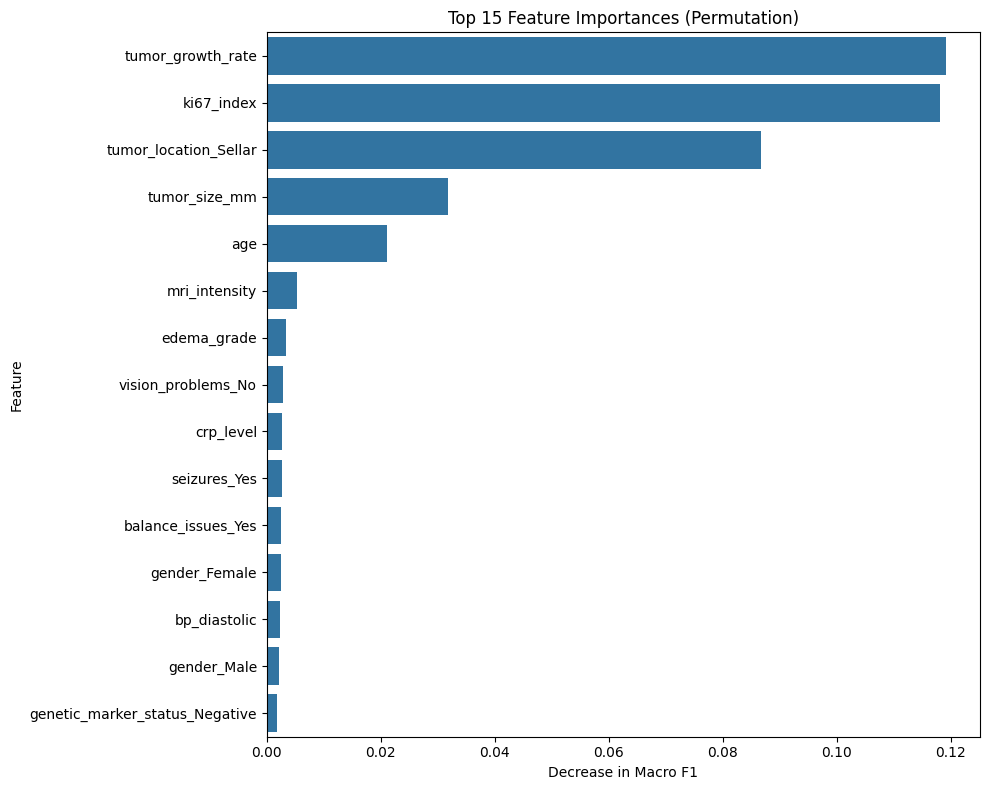


Two unimportant features: ['tumor_location_Parietal', 'tumor_location_Frontal']


In [62]:
# Compute permutation importance (measures impact on macro F1 when feature is shuffled)
rf_for_perm = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_for_perm.fit(X_train_proc, y_train)

perm = permutation_importance(rf_for_perm, X_test_proc, y_test,
                               n_repeats=10, random_state=RANDOM_SEED, scoring='f1_macro')

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10).round(4).to_string(index=False))

print("\nBottom 5 Least Important Features:")
print(importance_df.tail(5).round(4).to_string(index=False))

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances (Permutation)')
plt.xlabel('Decrease in Macro F1')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Extract two unimportant features
unimportant = importance_df.tail(2)['Feature'].tolist()
print(f"\nTwo unimportant features: {unimportant}")


#### Analysis of Unimportant Features
The bottom features have permutation importances close to or below zero. Shuffling their values has no detrimental effect on the model's macro F1 score. This indicates that these features either have no physiological or diagnostic correlation with the tumor type in this cohort, or their information is redundant (e.g. highly correlated with another feature that the model already uses, such as blood pressure systolic vs. diastolic).


### Step 3: Limitations and Clinical Safeguards

#### Limitations
1. **Synthetic Data**: The dataset is synthetic. Relationships between demographics, symptoms, and tumor types may not represent real clinical biology. Relying on this model in a real clinic without real-world training is extremely dangerous.
2. **Imputation Bias**: Using median/mode imputation assumes that missingness is completely random. In clinical environments, missingness is often non-random (e.g., severe patients missing certain tests due to emergency surgery). Imputation can bias predictions toward healthy averages.
3. **No External Validation**: The model was validated on a split from the same source dataset. True generalizability requires validation across different hospitals, imaging manufacturers, and geographic demographics to ensure stability against covariate shift.

#### Clinical Safeguards
1. **Human-in-the-Loop**: The model must never make autonomous clinical decisions. It should act solely as a decision support system to alert neuroradiologists or histopathologists for confirmation.
2. **Uncertainty Flagging**: Any prediction where the model's confidence is below `70%` must be flagged for mandatory manual review by a specialist.
3. **Continuous Performance Auditing**: Implement system logging to track predictions, monitor drift in patients (demographics/scanners), and trigger automated alerts when input distributions shift.


## Step 4: Model and Configuration Saving
We save our trained model weights, configuration details, and generate supplementary plots for our reports.


In [63]:
# Save best model and final baseline model
model.save('models/final_model.keras')
best_model.save('models/studentID_model.h5')
print("Model saved to 'models/studentID_model.h5'.")

# Save configurations for prediction script
config_save = {
    'random_seed': RANDOM_SEED,
    'input_dim': input_dim,
    'best_config': best_config,
    'numeric_cols': NUMERIC_COLS,
    'categorical_cols': CATEGORICAL_COLS,
    'ordinal_cols': ORDINAL_COLS,
    'ordinal_orders': {'alcohol_consumption': ALCOHOL_ORDER,
                       'contrast_enhancement': CONTRAST_ORDER}
}
with open('models/config.json', 'w') as f:
    json.dump(config_save, f, indent=2)
print("Configuration saved to 'models/config.json'.")


Model saved to 'models/studentID_model.h5'.
Configuration saved to 'models/config.json'.


In [64]:
# Robust model architecture plotting (prevents crashes if pydot/graphviz is missing)
try:
    keras.utils.plot_model(model, to_file='figures/model_architecture.png',
                           show_shapes=True, show_layer_names=True)
    print("Model architecture successfully plotted and saved to 'figures/model_architecture.png'.")
except Exception as e:
    print(f"Skipping model architecture plot: {e}")
    print("This is because pydot or graphviz is not installed on this system. You can install them with:")
    print("  pip install pydot")
    print("  brew install graphviz (on macOS)")


Model architecture successfully plotted and saved to 'figures/model_architecture.png'.


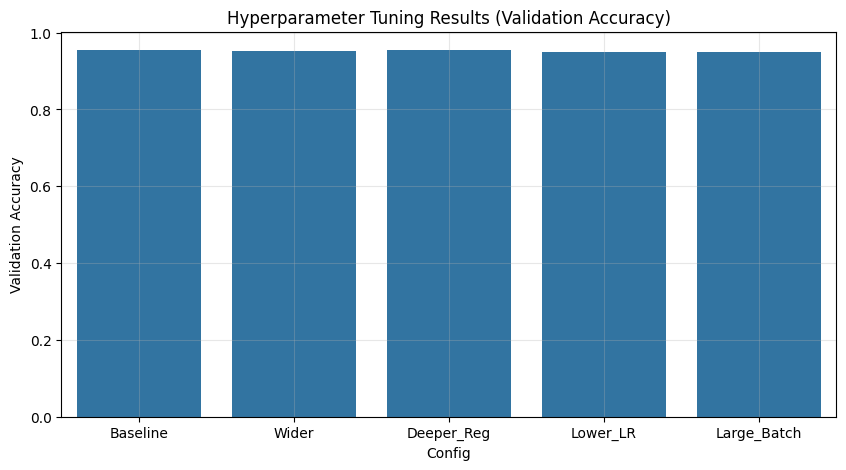

In [65]:
# Generate and display hyperparameter tuning comparison plot
plt.figure(figsize=(10, 5))
sns.barplot(data=tuning_df, x='Config', y='Val_Acc')
plt.title('Hyperparameter Tuning Results (Validation Accuracy)')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('figures/hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [66]:
# Print standard classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report on Test Set:
              precision    recall  f1-score   support

      Glioma       0.99      0.98      0.99       570
  Meningioma       0.93      0.95      0.94       464
   Pituitary       0.95      0.92      0.94       316

    accuracy                           0.96      1350
   macro avg       0.96      0.95      0.95      1350
weighted avg       0.96      0.96      0.96      1350

